# OOD Detection Intuition: Why Softmax Confidence Is a Poor OOD Signal

This is the motivating toy example for the out-of-distribution (OOD) detection ramp. We build a
simple 3-class 2D dataset, fit a classifier, and look at its confidence (max softmax probability,
MSP) over a grid that extends **far beyond** the training data.

The punchline: a classifier's softmax confidence answers *"which of my known classes does this look
like"*, not *"have I seen anything like this before"*. Softmax confidence stays high arbitrarily far
from the training data, because softmax is a **relative** comparison between classes -- it has no
notion of "none of the above". A density-based score, by contrast, correctly collapses in regions
with no training data, because it directly asks "how likely is a point like this under the training
distribution".


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture

SEED = 0
print("Setup complete, seed =", SEED)

Setup complete, seed = 0


## 1. A simple 3-class 2D dataset

Three well-separated Gaussian blobs, a few hundred points each. This is about as easy a
classification problem as exists -- the point isn't classifier accuracy, it's what happens to the
classifier's *confidence* once we leave this tidy region.


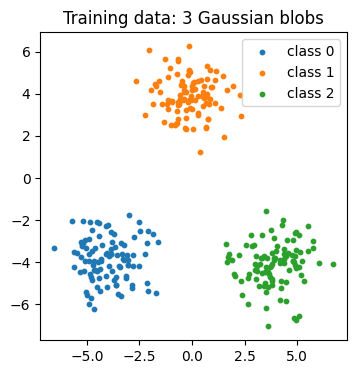

In [2]:
centers = [(-4, -4), (0, 4), (4, -4)]
X, y = make_blobs(
    n_samples=300, centers=centers, cluster_std=1.0, random_state=SEED
)

plt.figure(figsize=(4, 4))
for c in range(3):
    plt.scatter(X[y == c, 0], X[y == c, 1], s=10, label=f"class {c}")
plt.legend()
plt.title("Training data: 3 Gaussian blobs")
plt.gca().set_aspect("equal")
plt.show()

## 2. Fit a classifier and look at max-softmax-probability (MSP)

Logistic regression's `predict_proba` is a softmax over class scores. MSP = the largest predicted
class probability at a point. It's a common (cheap, always-available) proxy for "am I confident /
should I trust this prediction". We'll evaluate it over a grid spanning **way** beyond the training
data, not just near it.


In [3]:
clf = LogisticRegression().fit(X, y)

grid_extent = 15  # training data lives roughly within +-6, grid goes to +-15
xx, yy = np.meshgrid(
    np.linspace(-grid_extent, grid_extent, 200),
    np.linspace(-grid_extent, grid_extent, 200),
)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

proba = clf.predict_proba(grid_points)
msp = proba.max(axis=1).reshape(xx.shape)

print("MSP range over the grid:", round(msp.min(), 3), "to", round(msp.max(), 3))

MSP range over the grid: 0.356 to 1.0


## 3. Fit a density model and compare

Now fit a Gaussian mixture model directly on the training points (ignoring labels -- we just want
"what does the training distribution look like"). Its log-density is a genuine OOD score: it asks
how plausible a point is under the data we've actually seen, with no forced choice between classes.


In [4]:
gmm = GaussianMixture(n_components=3, random_state=SEED).fit(X)
log_density = gmm.score_samples(grid_points).reshape(xx.shape)

print("log-density range over the grid:", round(log_density.min(), 1), "to", round(log_density.max(), 1))

log-density range over the grid: -217.1 to -2.8


## 4. Side-by-side: softmax confidence vs. density

Same grid, same training points overlaid on both. Watch what happens near the edges of the plane,
far from any training data.


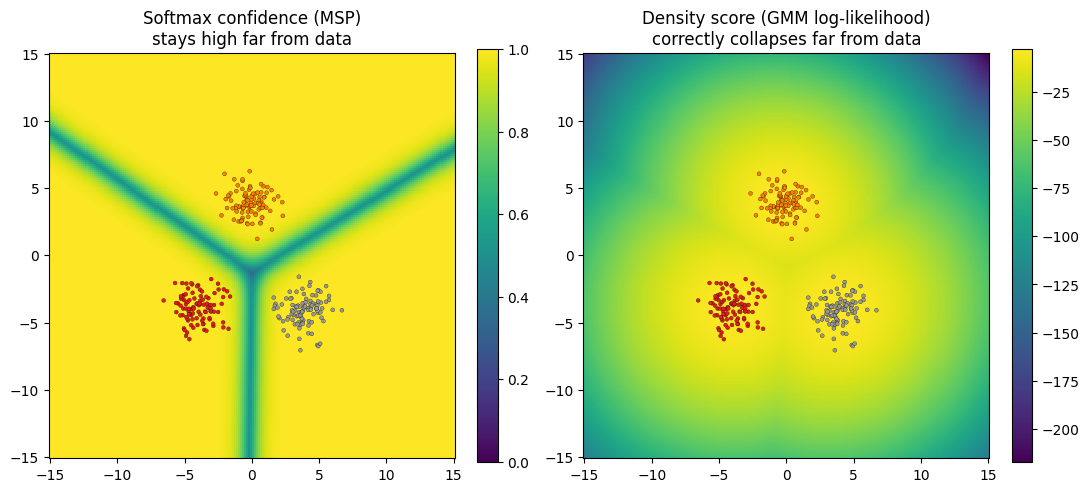

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Panel 1: MSP heatmap -- stays high almost everywhere, including empty corners
im0 = axes[0].pcolormesh(xx, yy, msp, cmap="viridis", vmin=0, vmax=1, shading="auto")
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="Set1", s=8, edgecolors="k", linewidths=0.2)
axes[0].set_title("Softmax confidence (MSP)\nstays high far from data")
axes[0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# Panel 2: log-density heatmap -- correctly collapses away from training data
im1 = axes[1].pcolormesh(xx, yy, log_density, cmap="viridis", shading="auto")
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="Set1", s=8, edgecolors="k", linewidths=0.2)
axes[1].set_title("Density score (GMM log-likelihood)\ncorrectly collapses far from data")
axes[1].set_aspect("equal")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 5. Quantify it: confidence at a point nobody trained on

Take a point in a far corner of the grid -- (14, 14) -- nowhere near any training data. Compare the
classifier's confidence there against a point that actually sits inside the training data.


In [6]:
far_point = np.array([[14.0, 14.0]])
far_msp = clf.predict_proba(far_point).max()
far_logdensity = gmm.score_samples(far_point)[0]

near_point = X[0:1]
near_msp = clf.predict_proba(near_point).max()
near_logdensity = gmm.score_samples(near_point)[0]

print(f"Far point  (14, 14) : MSP = {far_msp:.3f}   log-density = {far_logdensity:.1f}")
print(f"Near point (in-data): MSP = {near_msp:.3f}   log-density = {near_logdensity:.1f}")

Far point  (14, 14) : MSP = 1.000   log-density = -186.3
Near point (in-data): MSP = 0.998   log-density = -3.4


## Takeaway

- **Softmax confidence measures "which of my known classes is this most like," not "is this like
  anything I've trained on."** Because softmax is a normalized comparison across classes, one
  class's score can dominate the others (so MSP stays high) even infinitely far from any training
  data -- for a linear classifier, decision regions are unbounded half-planes, and confidence only
  *grows* the further you move from the boundary.
- **A density-based score asks the right question.** GMM log-likelihood (or KDE, or a per-class
  Mahalanobis distance) directly measures how plausible a point is under the training distribution,
  so it correctly collapses far from the data -- exactly the OOD signal we want.
- This is why the rest of this ramp explores density- and distance-based OOD scores instead of
  relying on softmax confidence alone.
